In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions
)

from tensorflow.keras.preprocessing import image
from google.colab import files


In [18]:
model = MobileNetV2(weights="imagenet")

print("CNN model loaded successfully!")


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN model loaded successfully!


In [3]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded image:", filename)


Saving WhatsApp Image 2026-07-25 at 1.42.38 PM.jpeg to WhatsApp Image 2026-07-25 at 1.42.38 PM.jpeg
Uploaded image: WhatsApp Image 2026-07-25 at 1.42.38 PM.jpeg


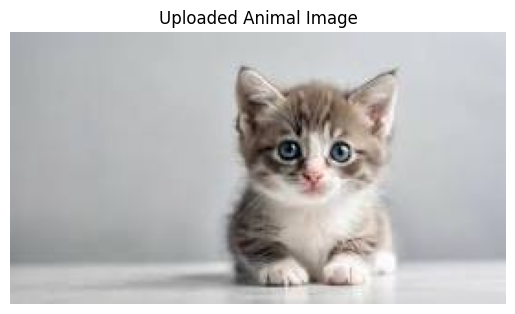

In [4]:
original_image = image.load_img(filename)

plt.imshow(original_image)
plt.title("Uploaded Animal Image")
plt.axis("off")
plt.show()


In [5]:
img = image.load_img(
    filename,
    target_size=(224, 224)
)


In [6]:
img_array = image.img_to_array(img)

In [7]:
img_array = np.expand_dims(
    img_array,
    axis=0
)


In [17]:
img_array = preprocess_input(img_array)

In [19]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [20]:
results = decode_predictions(
    predictions,
    top=3
)[0]


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
print("\nTop 3 Predictions:")

for number, result in enumerate(results, start=1):

    predicted_name = result[1].replace("_", " ")
    confidence = result[2] * 100

    print(
        f"{number}. {predicted_name}: "
        f"{confidence:.2f}%"
    )



Top 3 Predictions:
1. spotlight: 31.63%
2. digital clock: 3.33%
3. matchstick: 3.20%


In [22]:
best_name = results[0][1].replace("_", " ")
best_confidence = results[0][2] * 100


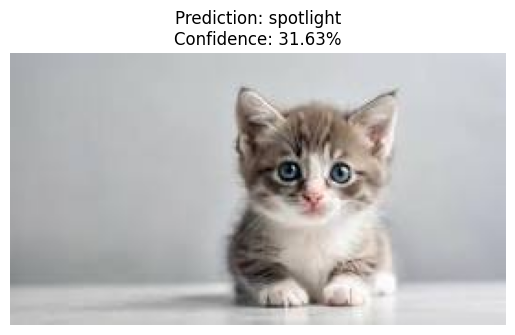

In [23]:
plt.imshow(original_image)

plt.title(
    f"Prediction: {best_name}\n"
    f"Confidence: {best_confidence:.2f}%"
)

plt.axis("off")
plt.show()
